<a href="https://colab.research.google.com/github/khaledmanaa11/AI_ORCHESTRATION_HW2/blob/master/Copy_of_hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 **Student 1 Name+ID

 **Student 2 Name+ID

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cpu


<Figure size 640x480 with 0 Axes>

In [6]:
# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([transforms.ToTensor(),transforms.Lambda(lambda x: ((x*255 + torch.rand_like(x))/256))])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


In [7]:
imgs, _ = next(iter(train_loader))
print(imgs.min(), imgs.max())

tensor(4.8894e-09) tensor(1.0000)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


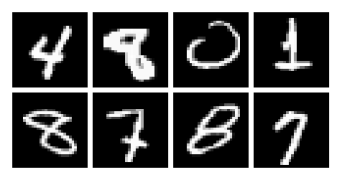

In [8]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

In [ ]:
class VAE(nn.Module):

    def __init__(self, latent_dim):
        super().__init__()

        self.latent_dim = latent_dim

        self.logs = defaultdict(list)

    def log(self, key, value):
        self.logs[key].append(value)

    def training_step(self, batch):
        loss, rec_loss, KLD = self.calc_elbo(batch)
        # Log losses
        self.log('train_elbo', loss.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD', KLD.item())
        return loss

    @torch.no_grad()
    def validation_step(self, loader):
        loss_obj = []
        for imgs, _ in tqdm(loader, leave=False):
          imgs = imgs.to(device)
          loss_obj.append(self.calc_elbo(imgs))

        loss_obj = torch.tensor(loss_obj)
        loss, rec_loss, KLD = loss_obj.mean(dim=0)
        # Log losses
        self.log('val_elbo', loss.item())
        self.log('val_recon', rec_loss.item())
        self.log('val_KLD', KLD.item())

        return loss

    @torch.no_grad()
    def test_step(self, loader):
        loss_obj = []
        for imgs, _ in tqdm(loader, leave=False):
          imgs = imgs.to(device)
          loss_obj.append(self.calc_elbo(imgs))

        loss_obj = torch.tensor(loss_obj)
        loss, rec_loss, KLD = loss_obj.mean(dim=0)
        # Log losses
        self.log('test_elbo', loss.item())
        self.log('test_recon', rec_loss.item())
        self.log('test_KLD', KLD.item())

        return loss

## Model Training

In [ ]:
model = None
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 5

In [ ]:
# Training loop
for epoch in range(epochs):
    model.train()
    losses = []

    for imgs, _ in tqdm(train_loader, leave=False):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs)
        loss.backward()
        optimizer.step()

    scheduler.step()
    model.validation_step(val_loader)

# Test loop
model.eval()

final_loss = model.test_step(test_loader)
print(f"Final ELBO: {final_loss}")

# Save the model
torch.save(model.state_dict(), 'vae_model.pth')